#### ============================================================================
#### 1. Import Libraries and Load Dataset
#### ============================================================================

In [2]:

 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Load the dataset
df = pd.read_csv(r"C:\Users\USER\Desktop\RUHUHAEXAM\OneDrive\Documentos\Stroke_Prediction\Flask_react_app\backend\healthcare-dataset-stroke-data.csv")
print(df.head())


      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


#### ============================================================================
#### 2. Define Features and Create Pipeline
#### ============================================================================

In [3]:

# Define numerical and categorical features
numerical = ['avg_glucose_level', 'bmi', 'age']
categorical = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 
               'Residence_type', 'smoking_status']

# Create numerical preprocessing pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', PowerTransformer(method='yeo-johnson', standardize=True))
])

# Create categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

# Combine both transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical),
        ('cat', categorical_transformer, categorical)
    ]
)

# Create final pipeline with preprocessing and SMOTE
pipeline = Pipeline(steps=[
    ('transformer', preprocessor),
    ('smote', SMOTE())
])


#### ============================================================================
#### 3. Prepare Data and Fit Pipeline
#### ============================================================================

In [4]:

print("\n=== PREPARING DATA ===")

# Prepare your data
y = df['stroke']
X = df.drop('stroke', axis=1)

# If 'id' column exists, drop it
if 'id' in X.columns:
    X = X.drop('id', axis=1)

print(f"Original data shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Fit the pipeline
X_transformed, y_resampled = pipeline.fit_resample(X, y)
print("\n * Pipeline fitted successfully!")

print(f"\nOriginal shape: {X.shape}")
print(f"Transformed shape: {X_transformed.shape}")

print(f"\nOriginal target distribution:")
print(f"  - No Stroke (0): {y.value_counts()[0]} ({y.value_counts()[0]/len(y)*100:.2f}%)")
print(f"  - Stroke (1): {y.value_counts()[1]} ({y.value_counts()[1]/len(y)*100:.2f}%)")

resampled_counts = pd.Series(y_resampled).value_counts()
print(f"\nResampled target distribution (after SMOTE):")
print(f"  - No Stroke (0): {resampled_counts[0]} ({resampled_counts[0]/len(y_resampled)*100:.2f}%)")
print(f"  - Stroke (1): {resampled_counts[1]} ({resampled_counts[1]/len(y_resampled)*100:.2f}%)")


=== PREPARING DATA ===
Original data shape: (5110, 10)
Target shape: (5110,)

 * Pipeline fitted successfully!

Original shape: (5110, 10)
Transformed shape: (9722, 20)

Original target distribution:
  - No Stroke (0): 4861 (95.13%)
  - Stroke (1): 249 (4.87%)

Resampled target distribution (after SMOTE):
  - No Stroke (0): 4861 (50.00%)
  - Stroke (1): 4861 (50.00%)


#### ============================================================================
#### 4. Visualize Class Distribution Before and After SMOTE
#### ============================================================================


=== CLASS BALANCE COMPARISON ===


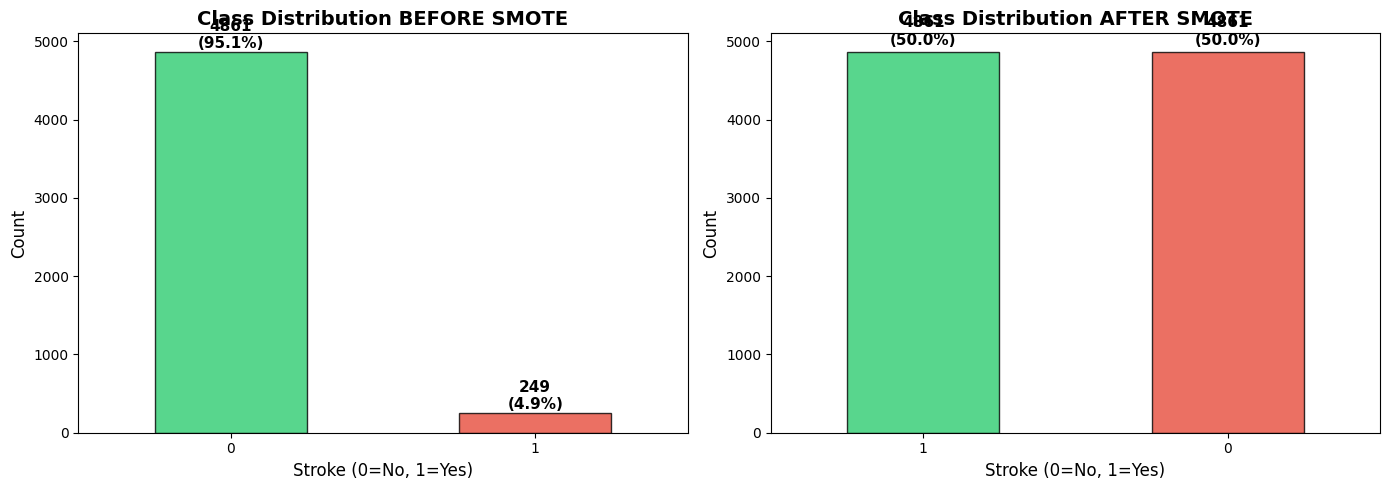

In [5]:

print("\n=== CLASS BALANCE COMPARISON ===")

plt.figure(figsize=(14, 5))

# Before SMOTE
plt.subplot(1, 2, 1)
colors_before = ['#2ecc71', '#e74c3c']
y.value_counts().plot(kind='bar', color=colors_before, alpha=0.8, edgecolor='black')
plt.title('Class Distribution BEFORE SMOTE', fontsize=14, fontweight='bold')
plt.xlabel('Stroke (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(y.value_counts().values):
    plt.text(i, v + 50, f'{v}\n({v/len(y)*100:.1f}%)', 
            ha='center', fontweight='bold', fontsize=11)

# After SMOTE
plt.subplot(1, 2, 2)
pd.Series(y_resampled).value_counts().plot(kind='bar', color=colors_before, 
                                            alpha=0.8, edgecolor='black')
plt.title('Class Distribution AFTER SMOTE', fontsize=14, fontweight='bold')
plt.xlabel('Stroke (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(pd.Series(y_resampled).value_counts().values):
    plt.text(i, v + 100, f'{v}\n({v/len(y_resampled)*100:.1f}%)', 
            ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

#### ============================================================================
#### 5. Compare Original vs Transformed Data (Numerical Features)
#### ============================================================================



=== ORIGINAL VS TRANSFORMED (Numerical Features) ===


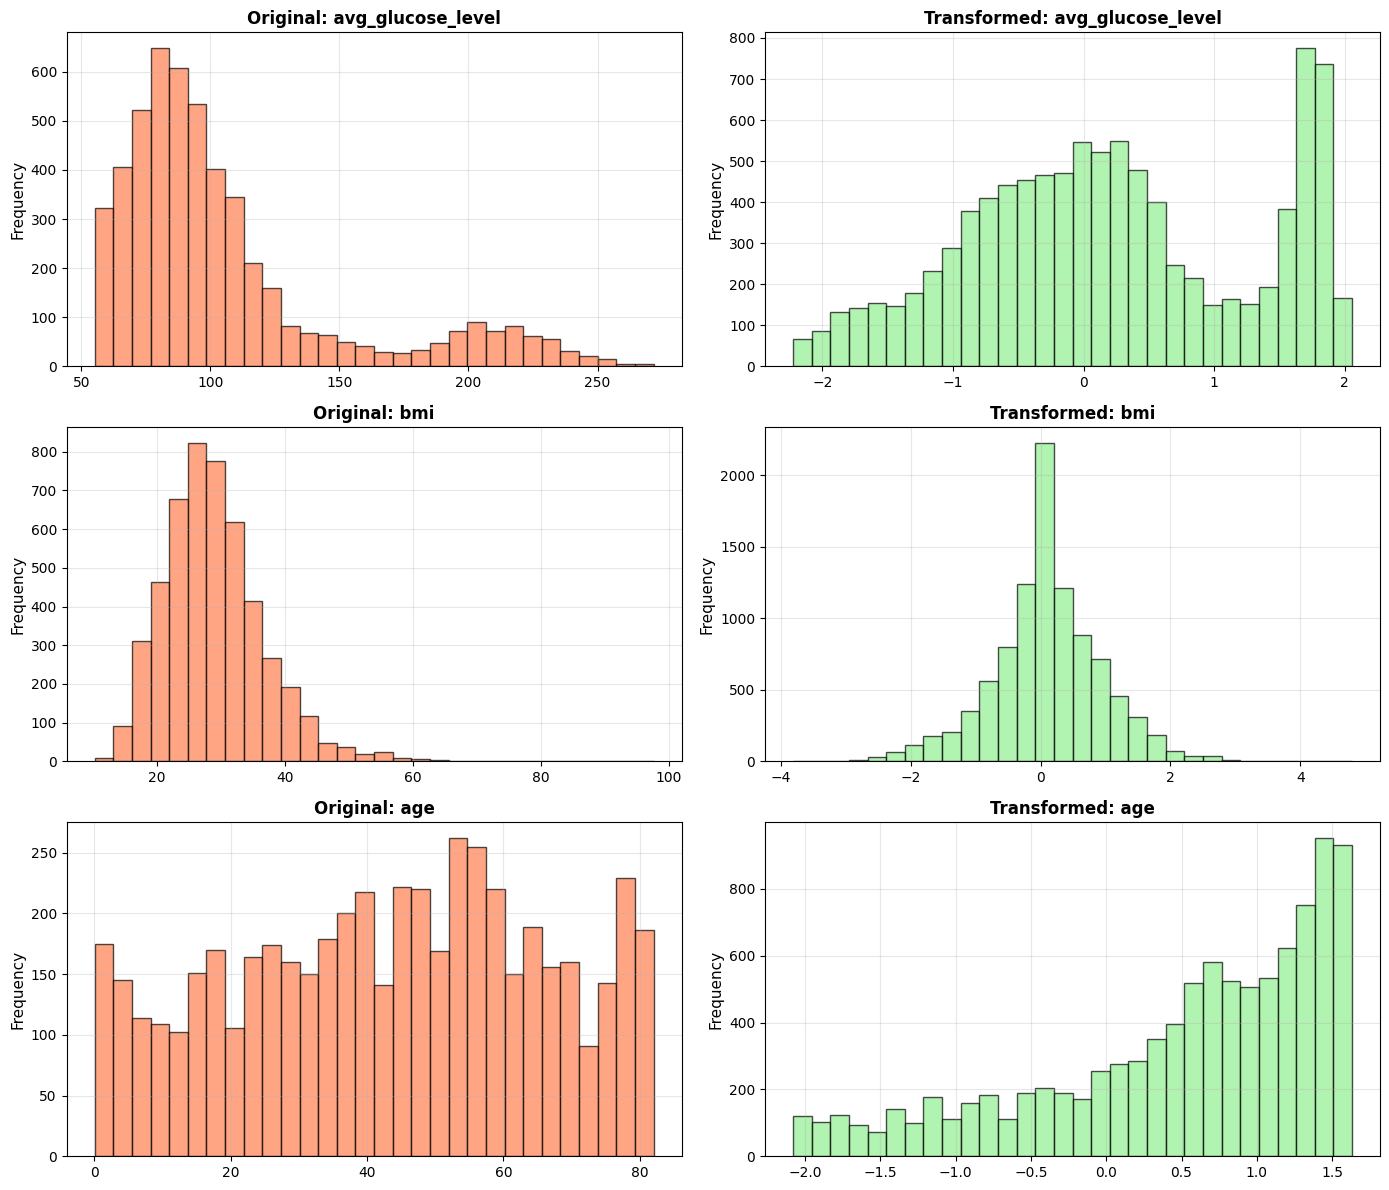

In [6]:

print("\n=== ORIGINAL VS TRANSFORMED (Numerical Features) ===")

fig, axes = plt.subplots(len(numerical), 2, figsize=(14, 4*len(numerical)))

for idx, col in enumerate(numerical):
    # Original
    axes[idx, 0].hist(X[col].dropna(), bins=30, color='coral', 
                     edgecolor='black', alpha=0.7)
    axes[idx, 0].set_title(f'Original: {col}', fontsize=12, fontweight='bold')
    axes[idx, 0].set_ylabel('Frequency', fontsize=11)
    axes[idx, 0].grid(alpha=0.3)
    
    # Transformed (get the corresponding column)
    col_idx = numerical.index(col)
    axes[idx, 1].hist(X_transformed[:, col_idx], bins=30, color='lightgreen', 
                     edgecolor='black', alpha=0.7)
    axes[idx, 1].set_title(f'Transformed: {col}', fontsize=12, fontweight='bold')
    axes[idx, 1].set_ylabel('Frequency', fontsize=11)
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### ============================================================================
#### 6. Pipeline Summary Report
#### ============================================================================

In [7]:

print("\n" + "="*70)
print(" "*20 + "PIPELINE VERIFICATION SUMMARY")
print("="*70)

print("\n* Pipeline Status: READY FOR MODEL TRAINING")
print(f"\n Pipeline Configuration:")
print(f"   • Total Pipeline Steps: {len(pipeline.steps)}")
print(f"   • Preprocessing Step: {pipeline.steps[0][0]}")
print(f"   • Resampling Step: {pipeline.steps[1][0]}")

print(f"\n Data Transformation:")
print(f"   • Input Features: {X.shape[1]}")
print(f"   • Output Features: {X_transformed.shape[1]}")
print(f"   • Feature Expansion: {X_transformed.shape[1] - X.shape[1]} new features (from encoding)")

print(f"\n Sample Size:")
print(f"   • Samples Before SMOTE: {X.shape[0]}")
print(f"   • Samples After SMOTE: {X_transformed.shape[0]}")
print(f"   • New Samples Created: {X_transformed.shape[0] - X.shape[0]}")

print(f"\nClass Balance:")
print(f"   • Before: {y.value_counts()[0]}:{y.value_counts()[1]} (imbalanced)")
print(f"   • After: {pd.Series(y_resampled).value_counts()[0]}:{pd.Series(y_resampled).value_counts()[1]} (balanced)")

print(f"\n Data Processing Steps Completed:")
print(f"   * Missing Values Imputed (Median for numerical, Mode for categorical)")
print(f"   * Numerical Features Scaled (Yeo-Johnson transformation)")
print(f"   * Categorical Features Encoded (One-Hot Encoding)")
print(f"   * Class Imbalance Handled (SMOTE oversampling)")


                    PIPELINE VERIFICATION SUMMARY

* Pipeline Status: READY FOR MODEL TRAINING

 Pipeline Configuration:
   • Total Pipeline Steps: 2
   • Preprocessing Step: transformer
   • Resampling Step: smote

 Data Transformation:
   • Input Features: 10
   • Output Features: 20
   • Feature Expansion: 10 new features (from encoding)

 Sample Size:
   • Samples Before SMOTE: 5110
   • Samples After SMOTE: 9722
   • New Samples Created: 4612

Class Balance:
   • Before: 4861:249 (imbalanced)
   • After: 4861:4861 (balanced)

 Data Processing Steps Completed:
   * Missing Values Imputed (Median for numerical, Mode for categorical)
   * Numerical Features Scaled (Yeo-Johnson transformation)
   * Categorical Features Encoded (One-Hot Encoding)
   * Class Imbalance Handled (SMOTE oversampling)


## ============================================================================
## Model Training
## ============================================================================


## 1. Import libraries

In [8]:

from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Define Function to Get Models


In [9]:

def get_models():
    """
    Returns a dictionary of machine learning models and their names.
    """
    models = {}
    names = []
    
    # ===== LINEAR MODELS =====
    models['LR'] = LogisticRegression(solver='liblinear', max_iter=1000)
    names.append('LR')
    
    models['LDA'] = LinearDiscriminantAnalysis()
    names.append('LDA')
    
    # ===== TREE-BASED MODELS =====
    models['DT'] = DecisionTreeClassifier(random_state=42, max_depth=10)
    names.append('DT')
    
    models['RF'] = RandomForestClassifier(n_estimators=100, random_state=42)
    names.append('RF')
    
    models['ET'] = ExtraTreesClassifier(n_estimators=100, random_state=42)
    names.append('ET')
    
    # ===== BOOSTING MODELS =====
    models['GB'] = GradientBoostingClassifier(n_estimators=100, random_state=42)
    names.append('GB')
    
    models['ADA'] = AdaBoostClassifier(n_estimators=100, random_state=42)
    names.append('ADA')
    
    models['XGB'] = XGBClassifier(n_estimators=100, random_state=42, 
                                   eval_metric='logloss', use_label_encoder=False)
    names.append('XGB')
    
    models['LGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
    names.append('LGBM')
    
    # ===== OTHER MODELS =====
    models['KNN'] = KNeighborsClassifier(n_neighbors=5)
    names.append('KNN')
    
    models['NB'] = GaussianNB()
    names.append('NB')
    
    models['SVM'] = SVC(kernel='rbf', probability=True, random_state=42)
    names.append('SVM')
    
    models['MLP'] = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, 
                                   random_state=42)
    names.append('MLP')
    
    return models, names

#### ============================================================================
#### 3. Prepare Data
#### ============================================================================

In [10]:

# Load dataset (assuming df is already loaded)
y = df['stroke']
X = df.drop('stroke', axis=1)

# Drop ID column if it exists
if 'id' in X.columns:
    X = X.drop('id', axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (5110, 10)
Target shape: (5110,)



# 4. Define Evaluation Function


In [11]:

def evaluate_model(X, y, model):
    """
    Evaluates a model using cross-validation with RepeatedStratifiedKFold.
    
    Parameters:
    -----------
    X : array-like
        Features
    y : array-like
        Target variable
    model : estimator
        Machine learning model to evaluate
    
    Returns:
    --------
    scores : array
        ROC AUC scores from cross-validation
    """
    # Define cross-validation strategy
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
    
    # Perform cross-validation
    scores = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
    
    return scores



## 5.Create Preprocessing Pipeline

In [12]:

# Define numerical and categorical features
numerical = ['avg_glucose_level', 'bmi', 'age']
categorical = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 
               'Residence_type', 'smoking_status']

# Create numerical transformer
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', PowerTransformer(method='yeo-johnson', standardize=True))
])

# Create categorical transformer
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical),
        ('cat', categorical_transformer, categorical)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!



## 6.  Evaluate All Models

In [13]:

# Get models
models, names = get_models()
results = []

print("\n" + "="*70)
print("EVALUATING MODELS WITH SMOTE")
print("="*70 + "\n")

# Evaluate each model
for i in range(len(models)):
    model_name = names[i]
    print(f"Evaluating {model_name}...", end=" ")
    
    # Create pipeline with preprocessor, SMOTE, and model
    pipeline = Pipeline(steps=[
        ('transformer', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', list(models.values())[i])
    ])
    
    # Evaluate the pipeline
    scores = evaluate_model(X, y, pipeline)
    results.append(scores)
    
    # Print results
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"ROC-AUC = {mean_score:.3f} (+/- {std_score:.3f})")



EVALUATING MODELS WITH SMOTE

Evaluating LR... ROC-AUC = 0.836 (+/- 0.029)
Evaluating LDA... ROC-AUC = 0.837 (+/- 0.030)
Evaluating DT... ROC-AUC = 0.711 (+/- 0.054)
Evaluating RF... ROC-AUC = 0.777 (+/- 0.027)
Evaluating ET... ROC-AUC = 0.734 (+/- 0.032)
Evaluating GB... ROC-AUC = 0.800 (+/- 0.030)
Evaluating ADA... ROC-AUC = 0.822 (+/- 0.031)
Evaluating XGB... ROC-AUC = 0.775 (+/- 0.030)
Evaluating LGBM... ROC-AUC = 0.784 (+/- 0.028)
Evaluating KNN... ROC-AUC = 0.642 (+/- 0.036)
Evaluating NB... ROC-AUC = 0.787 (+/- 0.035)
Evaluating SVM... ROC-AUC = 0.779 (+/- 0.032)
Evaluating MLP... ROC-AUC = 0.724 (+/- 0.039)

EVALUATION COMPLETE



## 7. Visualize Model Comparison

C:\Users\USER\AppData\Local\Temp\ipykernel_34988\3118381491.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(results, labels=names, patch_artist=True,


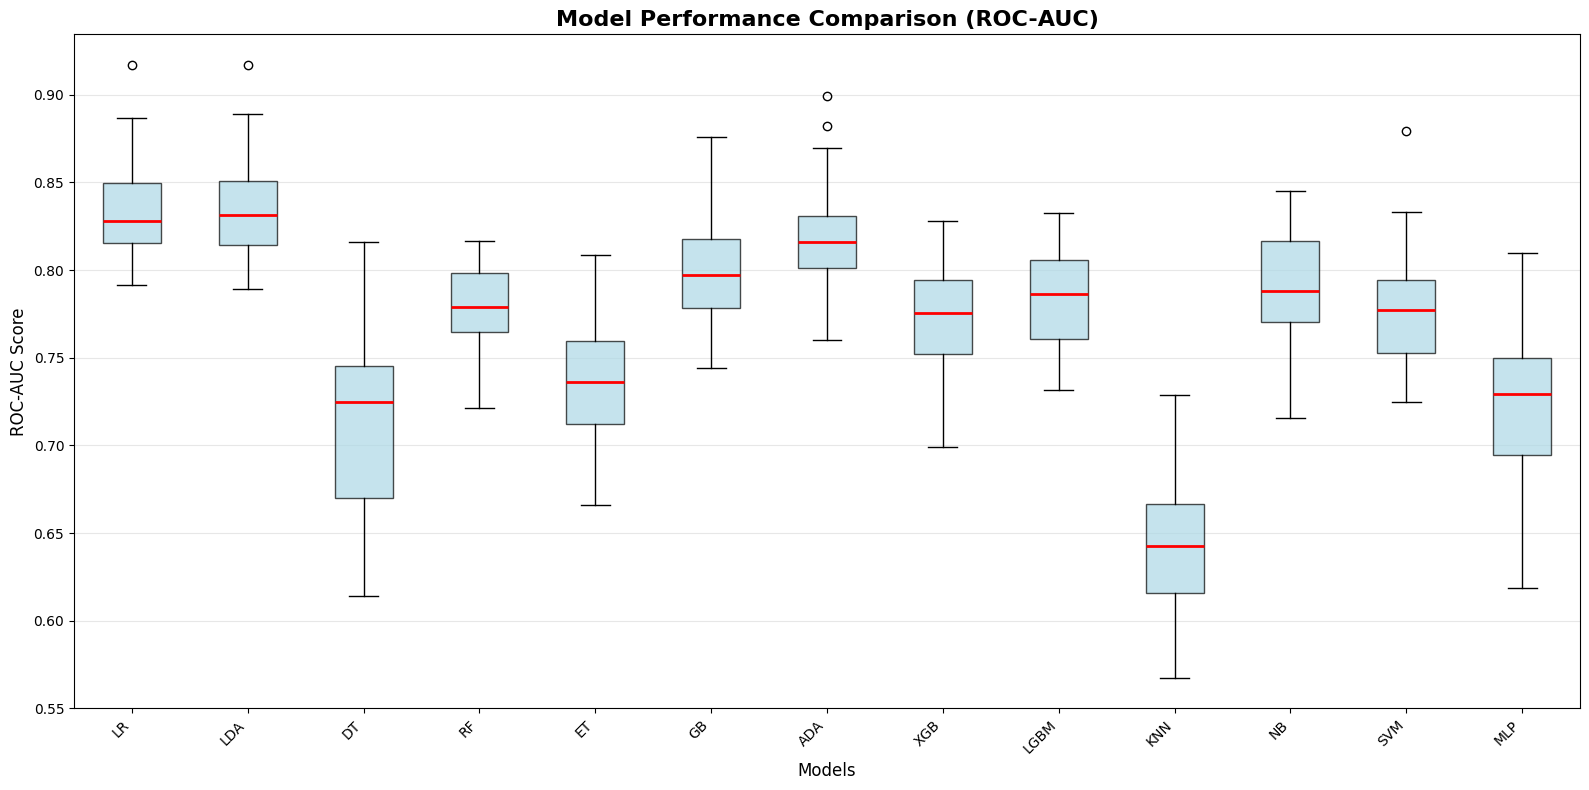

In [20]:

plt.figure(figsize=(16, 8))

# Create boxplot
bp = plt.boxplot(results, labels=names, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))

plt.title('Model Performance Comparison (ROC-AUC)', fontsize=16, fontweight='bold')
plt.xlabel('Models', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



# 8. Summary Statistics

In [21]:

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70 + "\n")

summary_df = pd.DataFrame({
    'Model': names,
    'Mean ROC-AUC': [np.mean(result) for result in results],
    'Std ROC-AUC': [np.std(result) for result in results],
    'Min ROC-AUC': [np.min(result) for result in results],
    'Max ROC-AUC': [np.max(result) for result in results]
})

summary_df = summary_df.sort_values('Mean ROC-AUC', ascending=False)
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print(f"BEST MODEL: {summary_df.iloc[0]['Model']} with ROC-AUC = {summary_df.iloc[0]['Mean ROC-AUC']:.4f}")
print("="*70)



SUMMARY STATISTICS

Model  Mean ROC-AUC  Std ROC-AUC  Min ROC-AUC  Max ROC-AUC
  LDA      0.837369     0.030084     0.789100     0.916955
   LR      0.835506     0.029019     0.791239     0.916955
  ADA      0.822016     0.030790     0.760288     0.899300
   GB      0.800015     0.030120     0.744198     0.875802
   NB      0.787297     0.034950     0.715473     0.845185
 LGBM      0.783633     0.027788     0.731348     0.832593
  SVM      0.779219     0.032094     0.724609     0.879424
   RF      0.777308     0.027296     0.721070     0.816461
  XGB      0.775452     0.030032     0.699093     0.827901
   ET      0.734037     0.032087     0.665761     0.808683
  MLP      0.723837     0.038825     0.618601     0.809465
   DT      0.710643     0.054045     0.613909     0.815844
  KNN      0.642013     0.035564     0.567449     0.728765

BEST MODEL: LDA with ROC-AUC = 0.8374



# 9. Top 5 Models Comparison


TOP 5 MODELS

Model  Mean ROC-AUC  Std ROC-AUC  Min ROC-AUC  Max ROC-AUC
  LDA      0.837369     0.030084     0.789100     0.916955
   LR      0.835506     0.029019     0.791239     0.916955
  ADA      0.822016     0.030790     0.760288     0.899300
   GB      0.800015     0.030120     0.744198     0.875802
   NB      0.787297     0.034950     0.715473     0.845185


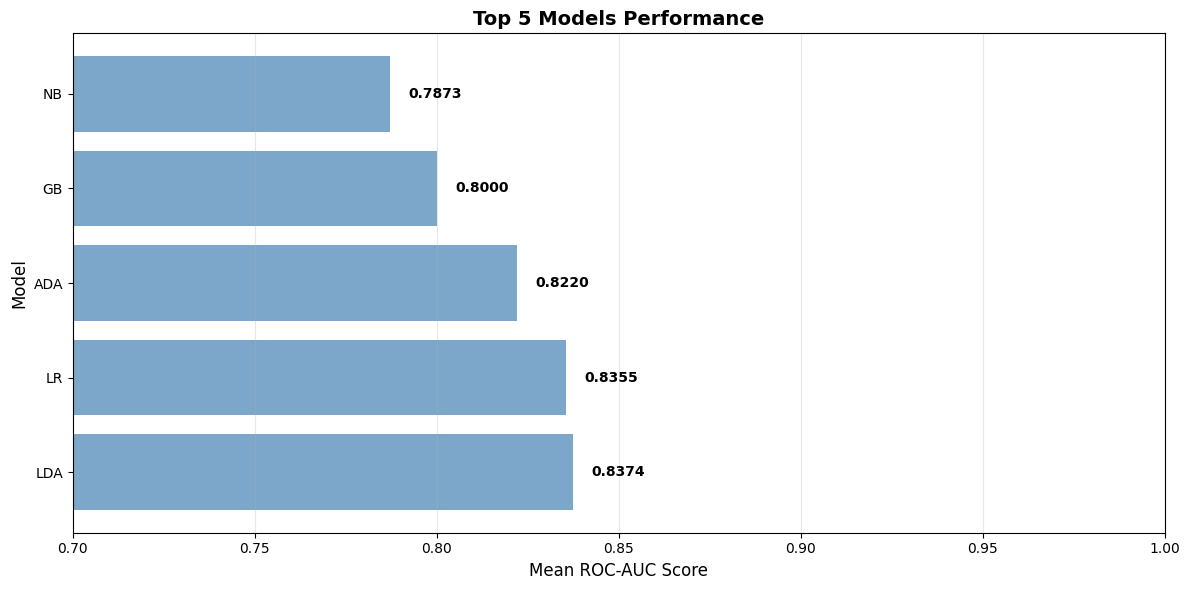

In [22]:

print("\n" + "="*70)
print("TOP 5 MODELS")
print("="*70 + "\n")

top5 = summary_df.head(5)
print(top5.to_string(index=False))

# Visualize top 5
plt.figure(figsize=(12, 6))
plt.barh(top5['Model'], top5['Mean ROC-AUC'], color='steelblue', alpha=0.7)
plt.xlabel('Mean ROC-AUC Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.title('Top 5 Models Performance', fontsize=14, fontweight='bold')
plt.xlim(0.7, 1.0)
for i, v in enumerate(top5['Mean ROC-AUC']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Detailed Model Performance

In [23]:

print("\n" + "="*70)
print("DETAILED CROSS-VALIDATION SCORES (TOP 5)")
print("="*70 + "\n")

top5_indices = [names.index(model) for model in top5['Model']]

for idx in top5_indices:
    name = names[idx]
    print(f"\n{name} Model:")
    print(f"  All Scores: {results[idx][:5]}...")  # Show first 5 scores
    print(f"  Mean: {np.mean(results[idx]):.4f}")
    print(f"  Median: {np.median(results[idx]):.4f}")
    print(f"  Std Dev: {np.std(results[idx]):.4f}")
    print(f"  Min: {np.min(results[idx]):.4f}")
    print(f"  Max: {np.max(results[idx]):.4f}")


DETAILED CROSS-VALIDATION SCORES (TOP 5)


LDA Model:
  All Scores: [0.85127572 0.81185185 0.84707819 0.81135802 0.87028807]...
  Mean: 0.8374
  Median: 0.8311
  Std Dev: 0.0301
  Min: 0.7891
  Max: 0.9170

LR Model:
  All Scores: [0.83786008 0.80847737 0.85127572 0.8109465  0.87382716]...
  Mean: 0.8355
  Median: 0.8279
  Std Dev: 0.0290
  Min: 0.7912
  Max: 0.9170

ADA Model:
  All Scores: [0.82600823 0.79761317 0.868107   0.7972428  0.84127572]...
  Mean: 0.8220
  Median: 0.8159
  Std Dev: 0.0308
  Min: 0.7603
  Max: 0.8993

GB Model:
  All Scores: [0.81950617 0.74419753 0.87580247 0.78510288 0.811893  ]...
  Mean: 0.8000
  Median: 0.7973
  Std Dev: 0.0301
  Min: 0.7442
  Max: 0.8758

NB Model:
  All Scores: [0.77946502 0.75884774 0.82987654 0.76711934 0.80880658]...
  Mean: 0.7873
  Median: 0.7879
  Std Dev: 0.0349
  Min: 0.7155
  Max: 0.8452
